In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter
cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])

import sys
sys.path.append('../src')
from continuous_losses import *
from scipy.integrate import cumtrapz

z_at_d = lambda dval: np.interp(dval, cosmo.luminosity_distance(np.logspace(-6, 1, 1000)).value, np.logspace(-6, 1, 1000))

/home/leonel/GitProjects/crisp/examples/../src/continuous_losses.py:35: RuntimeWarning: overflow encountered in exp
  fnu_eval = np.array([nuval**2 * np.trapz(phi(chi) / (np.exp(nuval * chi) - 1), chi) for nuval in nu_eval] )


# Studying single events like Amaterasu

This notebook attempts to evaluate the likelihood of single events following the steps in *Unger, Farrar ApjL Feb. 2024*

## Loading interaction core for extragalactic propagation

In [2]:
from core import *

data_files = {
    'path' : os.path.abspath('/home/leonel/GitProjects/CRPropa3/data-2021-07-30/data/'),
    
    'photodisintegration': {
        'rates_cmb' : 'Photodisintegration/rate_CMB.txt',
        'branchings_cmb' : 'Photodisintegration/branching_CMB.txt',
        'rates_ebl' : 'Photodisintegration/rate_EBL_LopezSaldana21.txt',
        'branchings_ebl' : 'Photodisintegration/branching_EBL_LopezSaldana21.txt',
    },

    'photopionproduction': {
        'rates_cmb' : 'PhotoPionProduction/rate_CMB.txt',
    } 
}

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Gilmore12.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Gilmore12.txt'

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Stecker16_upper.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Stecker16_upper.txt'

# ic1 = InteractionCore_CRPropA(data_files)
# ic1_cmb = InteractionCore_CRPropA_CMB_pdis(data_files)
# ic1_ebl = InteractionCore_CRPropA_IRB_pdis(data_files)
ic1_all = InteractionCore_CRPropA_pdis(data_files)

For nucleus (8, 14) some products were not found when creating light yields tensor.
For nucleus (7, 14) some products were not found when creating light yields tensor.
For nucleus (7, 13) some products were not found when creating light yields tensor.
For nucleus (6, 12) some products were not found when creating light yields tensor.
For nucleus (6, 10) some products were not found when creating light yields tensor.
For nucleus (5, 10) some products were not found when creating light yields tensor.
For nucleus (3, 6) some products were not found when creating light yields tensor.
problem with product [5. 9.] of nucleus (8, 14)
problem with product [5. 9.] of nucleus (7, 14)
problem with product [5. 9.] of nucleus (7, 13)
problem with product [5. 9.] of nucleus (6, 12)
problem with product [5. 9.] of nucleus (6, 10)
problem with product [5. 9.] of nucleus (5, 10)
problem with product [2. 5.] of nucleus (3, 6)
problem with product [3. 5.] of nucleus (3, 6)
problem with product [5. 9.] of

In [3]:
ic1 = ic1_all

## Likelihood 

Based on Figure 1 of the paper, computing the likelihood of products arriving from a source with Fe injection

In [4]:
def rig_dist_phasespace(Si=(26, 56), br=np.logspace(9.2, 11.3, 47), L=np.logspace(-1, 1.6, 50), daughters=None, lyields_On=True):
    """Computes the probability phase space in distance (L) and rigidity (br) for the detection
    on Earth of certain products (daughters) given a started injected species (Si) 
    
    Arguments:
    ----------
    Si: (Zi, Ai) injected nucleus
    br: boost range
    L: distances
    daughters: nuclear products to include in computation
    """
    light_daughters = [(2, 4), (2, 3), (1, 3), (1, 2), (1, 1), (0, 1)]
    Zi, Ai = Si
    contributions = []

    light_prods = None
    for Zdet, Adet in daughters:
        alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(Ai, Adet-1), injection_type=('only species', (Zi, Ai)), absorption_type=('only species', [(Zdet, Adet)]))
        
        if (Zdet, Adet) != Si:
            _, total1 = ic1.pdf_boost_range(L, alpha, mr, boost_range=br, true_range=tr)
            contributions.append(total1)
        elif (Zdet, Adet) == Si:
            idx = ic1.species.index(Si)
            _, total1 = ic1.pdf_boost_range(L, alpha, [idx], boost_range=br, true_range=[idx])
            contributions.append(total1)

        if lyields_On and ((Zdet, Adet) in light_daughters):
            if light_prods is None:
                light_prods = ic1.light_secondaries_production(L, alpha, mass_range=mr, boost_range=br, true_range=tr)
                cum_light_prods = cumtrapz(light_prods, L, initial=0)
                # cum_light_prods /= cum_light_prods[:, :, -1][:, :, None]
                inv_cum_light_prods = interp1d(L, cum_light_prods, bounds_error=False, fill_value=0)(L[-1] - L)
                # inv_cum_light_prods /= np.atleast_2d(inv_cum_light_prods[-1][:, 0]).T

            idx = light_daughters.index((Zdet, Adet))            
            contributions[-1] += inv_cum_light_prods[idx]

    return contributions

def apply_energy_weights(br=np.logspace(9.2, 11.3, 47), L=np.logspace(-1, 1.6, 50), daughters=None, Ex=1, sgm=2):
    """Computes the energy weights in probability phase space, i.e. distance (L) and rigidity (br) 
    for the detection on Earth of certain products (daughters) given a detected energy Ex with uncertainty sgm
    
    Arguments:
    ----------
    br: boost range
    L: distances
    daughters: nuclear products to include in computation
    """
    wE = []
    
    for _, Adet in daughters:
        wE.append(np.repeat(np.exp(-1/2*((Adet * br - Ex)/sgm)**2), len(L)).reshape(-1, len(L)))

    return wE

Text(45, 20.25, 'Fe $\\to$ He')

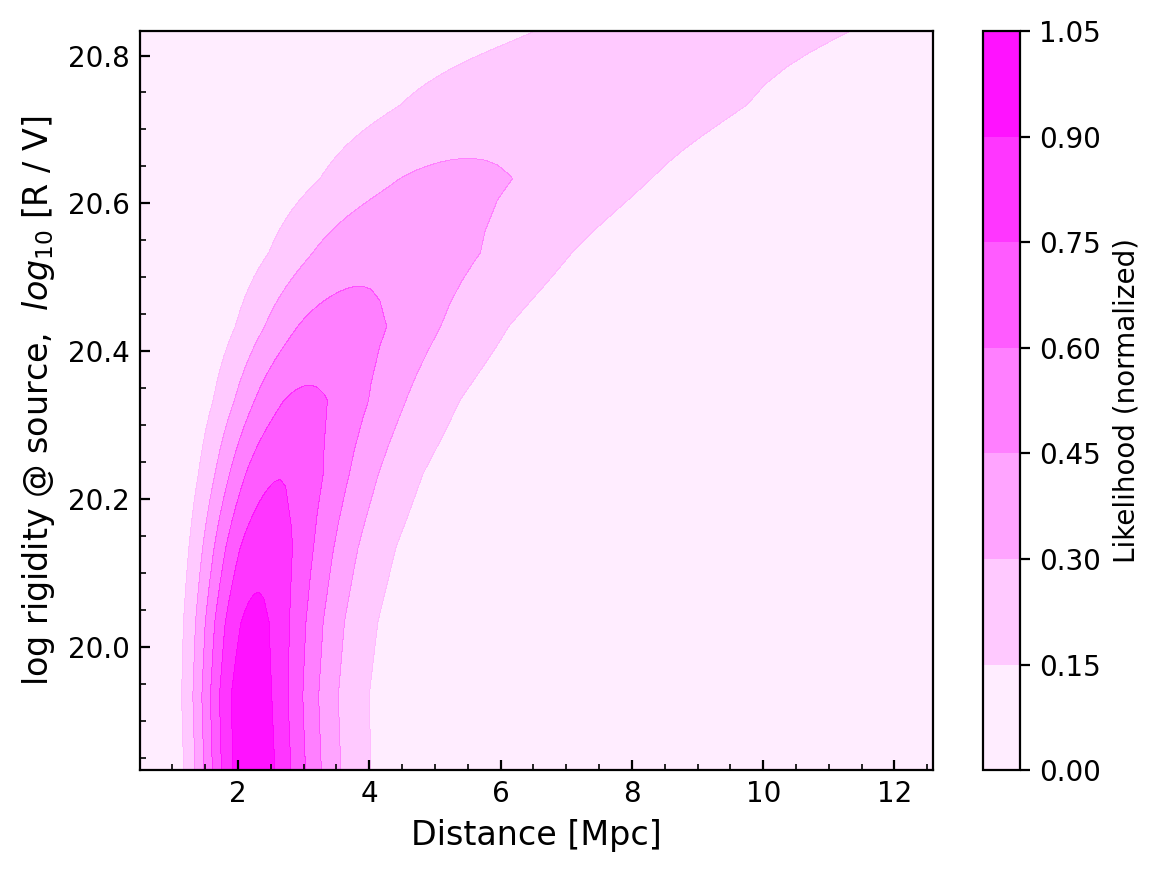

In [25]:
Zi, Ai = 26, 56
br = np.logspace(10.5, 11.5, 11)
L = np.logspace(-.3, 1.1, 100)

alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only species', [(2, 4)]))
_, total = ic1.pdf_boost_range(L, alpha, mr, boost_range=br, true_range=tr)
light_prods = ic1.light_secondaries_production(L, alpha, mass_range=mr, boost_range=br, true_range=tr)
cum_light_prods = cumulative_trapezoid(light_prods, L, initial=0)
inv_cum_light_prods = interp1d(L, cum_light_prods, bounds_error=False, fill_value=0)(L[-1] - L)
inv_cum_light_prods /= np.atleast_2d(inv_cum_light_prods[-1][:, 0]).T

plt.subplots(dpi=200)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), light_prods[-1], cmap=generate_cmap(cols[1]))
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), cum_light_prods[-1] / np.atleast_2d(cum_light_prods[-1][:, -1]).T)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), inv_cum_light_prods[5], cmap=generate_cmap(cols[1]))
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), total / np.max(total), cmap=generate_cmap(cols[2]))
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), total + inv_cum_light_prods[0])

plt.colorbar(label='Likelihood (normalized)')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

plt.annotate(r'Fe $\to$ He', (45, 20.25), fontsize=20)

boost: 3.98e+10
Rig.:8.57e+19


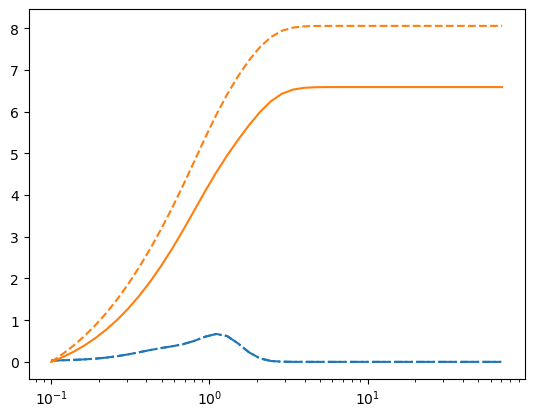

In [18]:
bidx = 1
# plt.semilogx(L, light_prods[-2][bidx, :], c='C0')
plt.semilogx(L, light_prods[0][bidx, :], c='C0', ls='--')
plt.semilogx(L, light_prods[-6][bidx, :], c='C0', ls='-.')
plt.semilogx(L, cum_light_prods[-2][bidx, :], c='C1')
plt.semilogx(L, cum_light_prods[-1][bidx, :], c='C1', ls='--')

# plt.loglog()
print(f'boost: {br[bidx]:3.2e}')
print(f'Rig.:{br[bidx] * 1e9 * Ai/Zi:3.2e}')

boost: 5.01e+10
Rig.:1.08e+20
boost: 1.58e+11
Rig.:3.41e+20


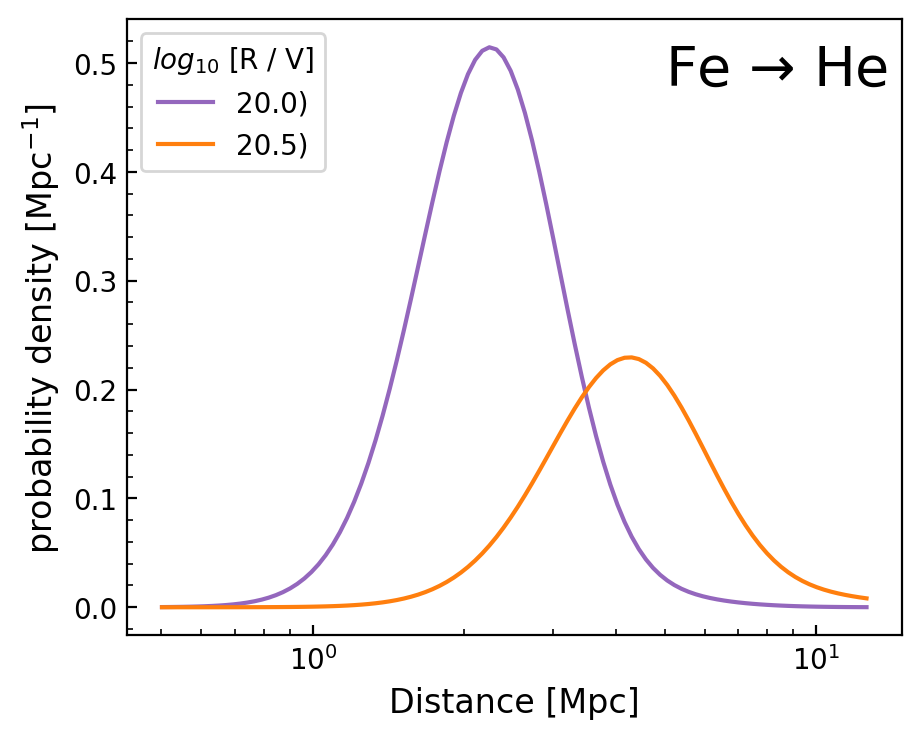

In [41]:
plt.subplots(dpi=200, figsize=(5, 4))

for bidx, col in zip([2, 7], ['C4', 'C1']):
    print(f'boost: {br[bidx]:3.2e}')
    print(f'Rig.:{br[bidx] * 1e9 * Ai/Zi:3.2e}')

    plt.semilogx(L, total[bidx, :], c=col, label=f'{np.log10(br[bidx] * 1e9 * Ai/Zi):2.1f})')

plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('probability density [Mpc$^{-1}$]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

plt.annotate(r'Fe $\to$ He', (5, 0.48), fontsize=20)
plt.legend(title=r'$log_{10}$ [R / V]', loc='upper left')

In [23]:
Zi, Ai = 26, 56
br = np.logspace(9.2, 11.3, 69)
L = np.logspace(-1, 1.85, 77)

alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only species', [(0, 1)]))
light_prods = ic1.light_secondaries_production(L, alpha, mass_range=mr, boost_range=br, true_range=tr)
cum_light_prods = cumtrapz(light_prods, L, initial=0)

plt.contourf(L, np.log10(1e9 * br * Ai/Zi), light_prods[-1])
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), cum_light_prods[-1])
plt.colorbar()

KeyboardInterrupt: 

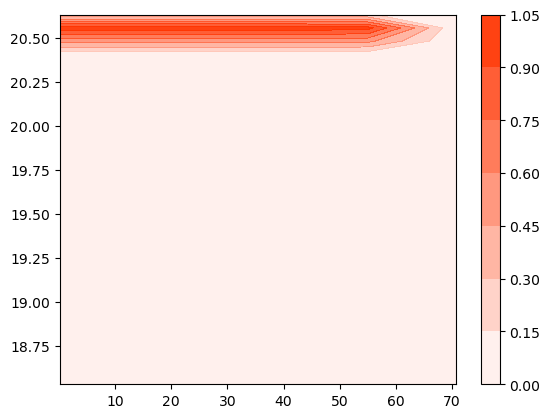

In [73]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
br = np.logspace(9.2, 11.3, 29)
L = np.logspace(-1, 1.85, 27)
contcont = rig_dist_phasespace(L=L, br=br, daughters=[(0, 1), (1, 1)])

col = cols[0]
nlevels = np.linspace(.007, 1, 5)
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters=[(0, 1), (1, 1)]
daughters=[(1, 1)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(contcont, wE)][:1])
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), cmap=groupcmap)
plt.colorbar()

Text(45, 20.25, 'Fe $\\to$ He')

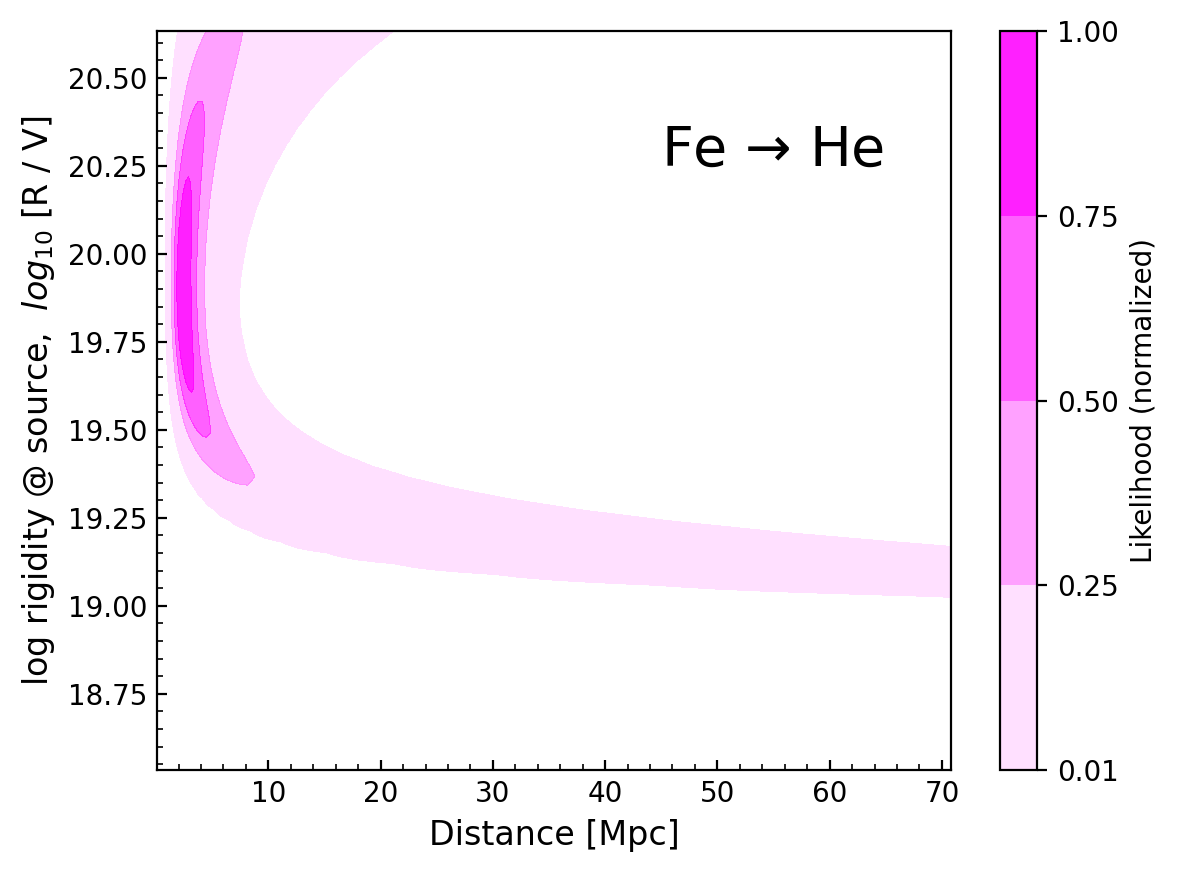

In [6]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
br = np.logspace(9.2, 11.3, 69)
L = np.logspace(-1, 1.85, 77)

Zlims = [1, 2, 7, 10, 15, 20, 25]
daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]
daughters = daughters_set(1, 2)

contcont = rig_dist_phasespace(L=L, br=br, daughters=daughters, lyields_On=False)


nlevels = np.logspace(-1, 0, 7)
nlevels = [.01, .25, .5, .75, 1]
groupcmap = generate_cmap(cols[2])

wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
# lklhood = sum([c * w for c, w in zip(contcont, wE)])
# lklhood[np.isnan(lklhood)] = 0
lklhood = sum(contcont)
# lklhood = contcont[-1]


plt.subplots(dpi=200)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood, levels=nlevels, cmap=groupcmap)


plt.colorbar(label='Likelihood (normalized)')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

plt.annotate(r'Fe $\to$ He', (45, 20.25), fontsize=20)
# plt.annotate(r'Fe $\to$ 7 < Z $\leq$ 10', (25, 20.25), fontsize=20)

Text(45, 20.25, 'Fe $\\to$ He')

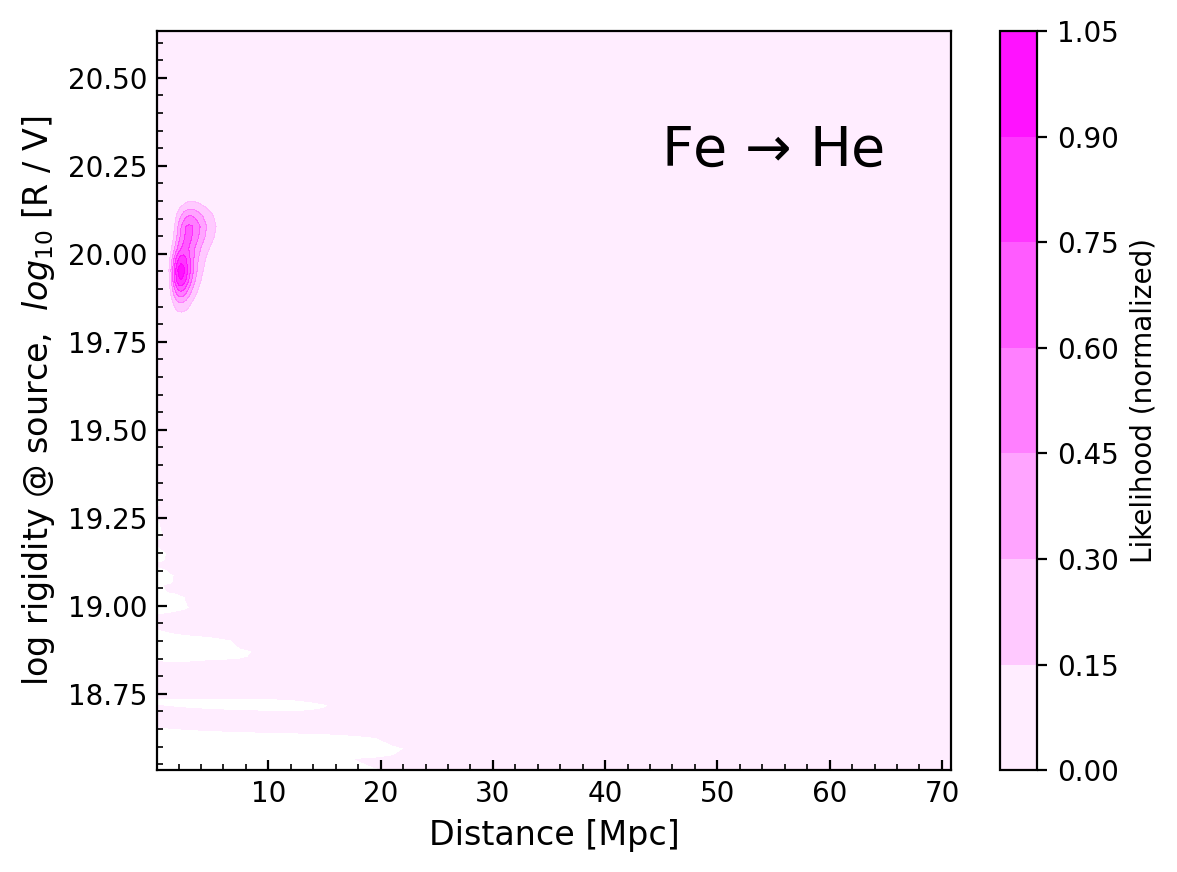

In [7]:
Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
br = np.logspace(9.2, 11.3, 69)
L = np.logspace(-1, 1.85, 77)

Zlims = [1, 2, 7, 10, 15, 20, 25]
daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]
daughters = daughters_set(1, 2)

# contcont = rig_dist_phasespace(L=L, br=br, daughters=daughters, lyields_On=False)


nlevels = np.logspace(-1, 0, 7)
nlevels = [.01, .25, .5, .75, 1]
groupcmap = generate_cmap(cols[2])

wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(contcont, wE)])
lklhood[np.isnan(lklhood)] = 0
# lklhood = sum(contcont)
# lklhood = contcont[-1]


plt.subplots(dpi=200)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), cmap=groupcmap)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood, levels=nlevels, cmap=groupcmap)


plt.colorbar(label='Likelihood (normalized)')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

plt.annotate(r'Fe $\to$ He', (45, 20.25), fontsize=20)
# plt.annotate(r'Fe $\to$ 7 < Z $\leq$ 10', (25, 20.25), fontsize=20)

Text(25, 20.25, 'Fe $\\to$ 7 < Z $\\leq$ 10')

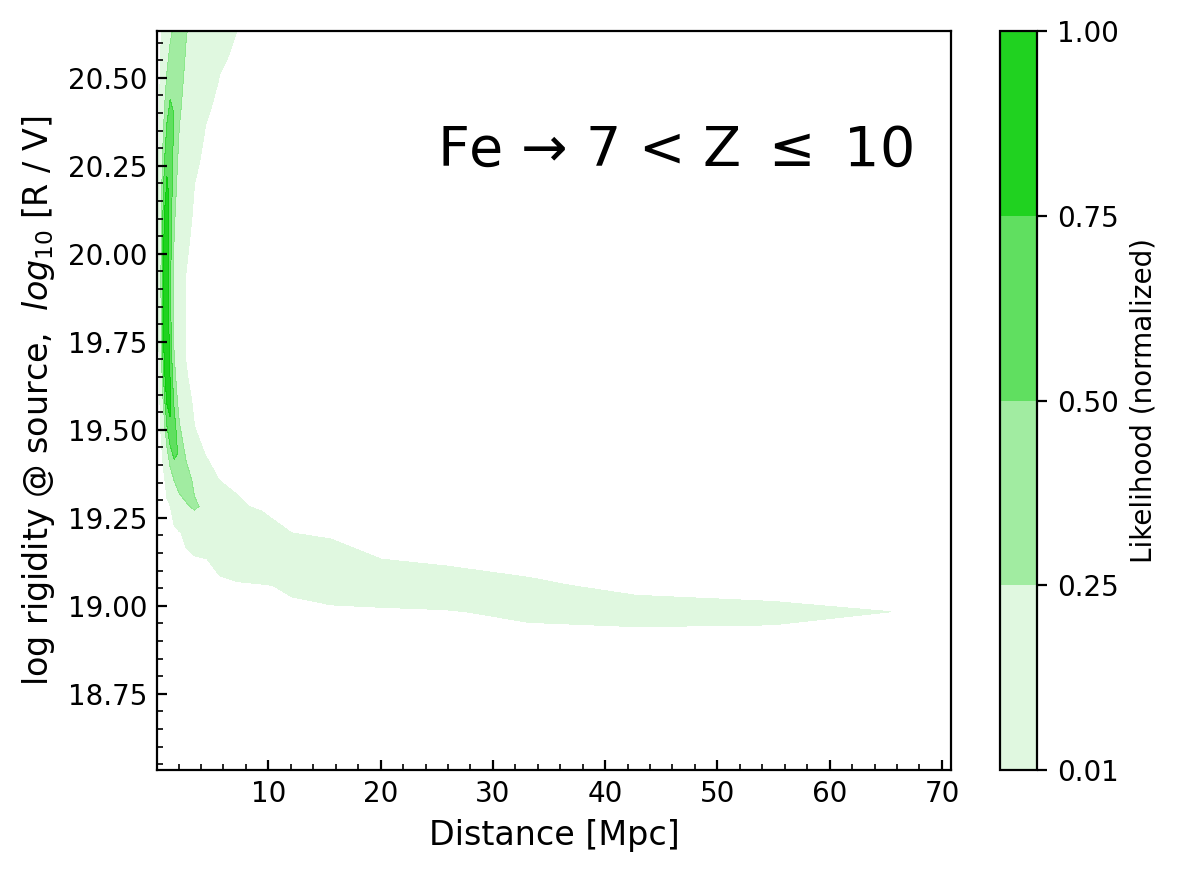

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
br = np.logspace(9.2, 11.3, 29)
L = np.logspace(-1, 1.85, 27)

Zlims = [1, 2, 7, 10, 15, 20, 25]
daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]
daughters = daughters_set(10, 15)

# contcont = rig_dist_phasespace(L=L, br=br, daughters=daughters)


nlevels = np.logspace(-1, 0, 7)
nlevels = [.01, .25, .5, .75, 1]
groupcmap = generate_cmap(cols[4])

wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
# lklhood = sum([c * w for c, w in zip(contcont, wE)])
# lklhood[np.isnan(lklhood)] = 0
lklhood = sum(contcont)
# lklhood = contcont[-1]


plt.subplots(dpi=200)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood, levels=nlevels, cmap=groupcmap)


plt.colorbar(label='Likelihood (normalized)')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

# plt.annotate(r'Fe $\to$ Z $\in (7, 10]$', (45, 20.25), fontsize=20)
plt.annotate(r'Fe $\to$ 7 < Z $\leq$ 10', (25, 20.25), fontsize=20)

Text(25, 20.25, 'Fe $\\to$ 7 < Z $\\leq$ 10')

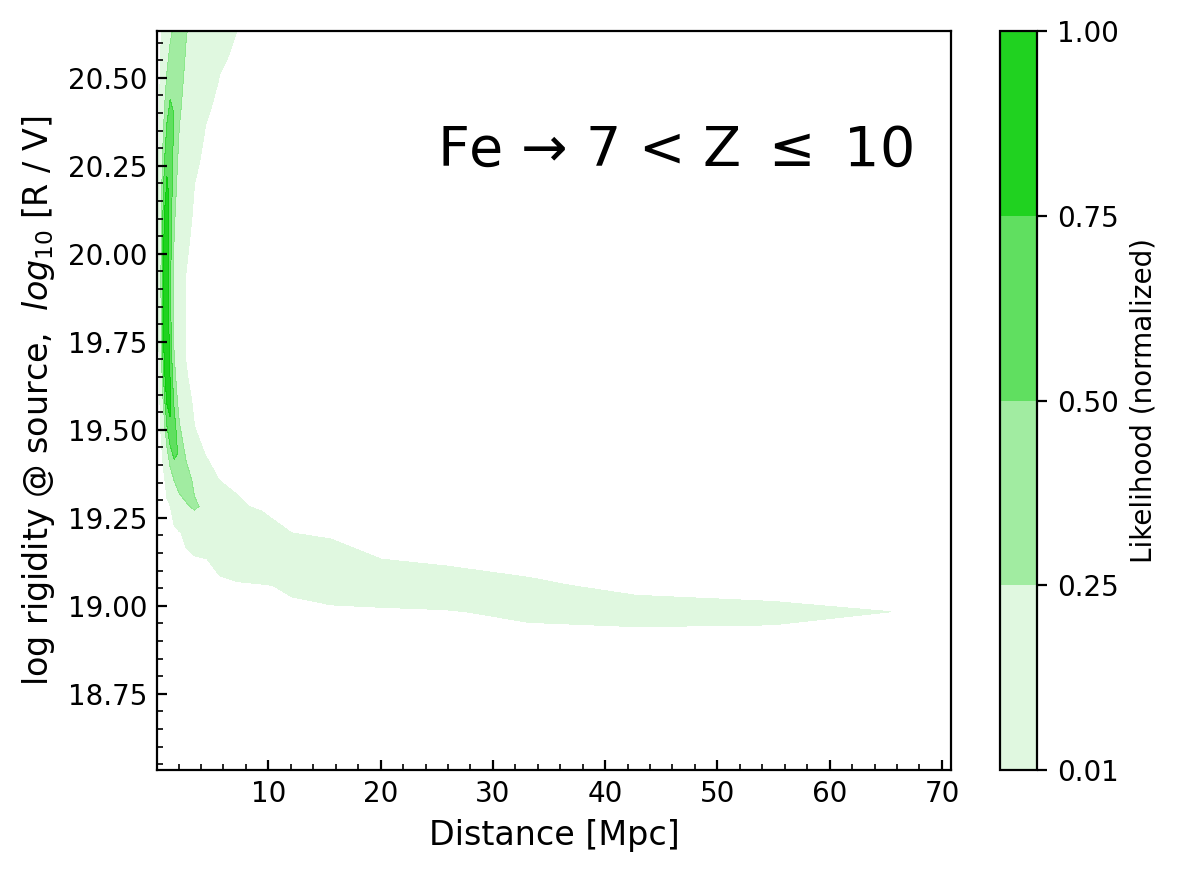

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
br = np.logspace(9.2, 11.3, 29)
L = np.logspace(-1, 1.85, 27)

Zlims = [1, 2, 7, 10, 15, 20, 25]
daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]
daughters = daughters_set(10, 15)

# contcont = rig_dist_phasespace(L=L, br=br, daughters=daughters)


nlevels = np.logspace(-1, 0, 7)
nlevels = [.01, .25, .5, .75, 1]
groupcmap = generate_cmap(cols[4])

wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
# lklhood = sum([c * w for c, w in zip(contcont, wE)])
# lklhood[np.isnan(lklhood)] = 0
lklhood = sum(contcont)
# lklhood = contcont[-1]


plt.subplots(dpi=200)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood, levels=nlevels, cmap=groupcmap)


plt.colorbar(label='Likelihood (normalized)')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()

# plt.annotate(r'Fe $\to$ Z $\in (7, 10]$', (45, 20.25), fontsize=20)
plt.annotate(r'Fe $\to$ 7 < Z $\leq$ 10', (25, 20.25), fontsize=20)

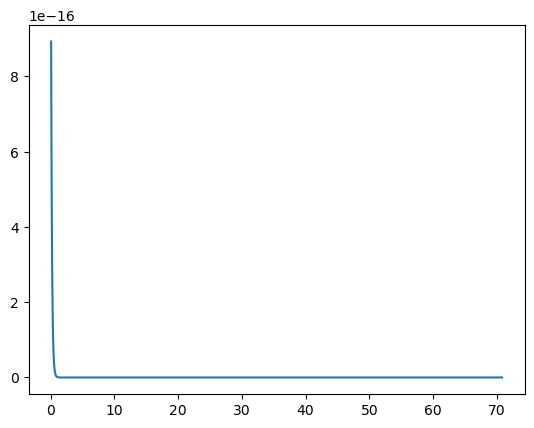

In [15]:
plt.plot(L, lklhood[28, :])

In [5]:
br = np.logspace(9.2, 11.3, 17)
br = np.logspace(9.2, 11.3, 69)

L = np.logspace(-1, 1.85, 19)
L = np.logspace(-1, 1.85, 77)

group_contributions = [rig_dist_phasespace(L=L, br=br, daughters=[(1, 1)]),
                       rig_dist_phasespace(L=L, br=br, daughters=[(1, 2)], lyields_On=False)]

Zlims = [1, 2, 7, 10, 15, 20, 25]

daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]

for zl, zh in zip(Zlims[:-1], Zlims[1:]):
    print(zl, zh)
    # Zvals = range(zl + 1, zh + 1)
    # daughters = [spec for spec in ic1.species if spec[0] in Zvals]
    daughters = daughters_set(zl, zh)

    contributions = rig_dist_phasespace(L=L, br=br, daughters=daughters, lyields_On=False)
    group_contributions.append(contributions)

group_contributions.append(rig_dist_phasespace(L=L, br=br, daughters=[(26, 56)]))

1 2
2 7
7 10
10 15
15 20
20 25


/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:312: RuntimeWarning: overflow encountered in cosh
  coshMu = np.cosh(mu)
/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:315: RuntimeWarning: overflow encountered in sinh
  sinchMu[mask] = np.sinh(mu[mask]) / mu[mask]
/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:317: RuntimeWarning: invalid value encountered in add
  eA[..., [0], [0]] = eApD2 * (coshMu + AmD2*sinchMu)
/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:318: RuntimeWarning: invalid value encountered in multiply
  eA[..., [0], [1]] = eApD2 * a2 * sinchMu
/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:319: RuntimeWarning: invalid value encountered in multiply
  eA[..., [1], [0]] = eApD2 * a3 * sinchMu
/home/leonel/anaconda3/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:320: RuntimeWarning: overflow encountered in subtract
  

In [69]:
np.save('group_contributions', group_contributions)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9,) + inhomogeneous part.

In [9]:
group_contributions = np.load('group_contributions.npy', allow_pickle=True)
# group_contributions = [contcont, ] + [gc for gc in group_contributions]

In [77]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
nlevels = np.logspace(-2, 0, 5)
nlevels = np.linspace(.1, 1, 4)

generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])


Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
Zlims = [1, 2, 7, 10, 15, 20, 25]


for daughters, lab, col, contrib in zip([[(1, 1)], [(1, 2)]], ['p', 'd'], cols[:2], group_contributions[:2]):
    # clow = colorConverter.to_rgba(col, alpha=0)
    # groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
    groupcmap = generate_cmap(col)

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
    plt.scatter([], [], label=lab, c=col)


for zl, zh, contrib, col in zip(Zlims[:-1], Zlims[1:], group_contributions[2:], cols[2:]):
    clow = colorConverter.to_rgba(col, alpha=0)
    groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])

    Zvals = range(zl + 1, zh + 1)
    daughters = [spec for spec in ic1.species if spec[0] in Zvals]

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    lklhood[np.isnan(lklhood)] = 0
    
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

    if zl == 1:
        plt.scatter([], [], label=f'He', c=col)
    else:
        plt.scatter([], [], label=f'{zl} $<$ Z $\leq$ {zh}', c=col)
    

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(26, 56)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.scatter([], [], label='Fe', c=col)


sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.zeros_like(lklhood), levels=[np.round(lv, 2) for lv in nlevels], 
                  cmap=LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba('k', alpha=0), 'k']))
plt.colorbar(label='Likelihood')
plt.ylim([18.6, 20.6])
plt.yticks(np.linspace(18.6, 20.6, 11));
plt.legend(loc='center right')
plt.xlabel('Distance [Mpc]')
plt.ylabel('$log_{10}$ [R / V]')
# plt.semilogx() 

ValueError: operands could not be broadcast together with shapes (69,77) (27,29) 

Text(0, 0.5, '$log_{10}$ [R / V]')

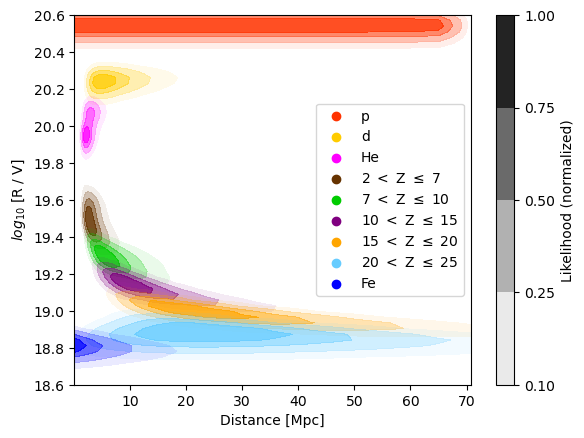

In [6]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
nlevels = np.logspace(-2, 0, 5)
nlevels = [.1, .25, .5, .75, 1]

generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])


Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
Zlims = [1, 2, 7, 10, 15, 20, 25]


for daughters, lab, col, contrib in zip([[(1, 1)], [(1, 2)]], ['p', 'd'], cols[:2], group_contributions[:2]):
    # clow = colorConverter.to_rgba(col, alpha=0)
    # groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
    groupcmap = generate_cmap(col)

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
    plt.scatter([], [], label=lab, c=col)


for zl, zh, contrib, col in zip(Zlims[:-1], Zlims[1:], group_contributions[2:], cols[2:]):
    clow = colorConverter.to_rgba(col, alpha=0)
    groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])

    Zvals = range(zl + 1, zh + 1)
    daughters = [spec for spec in ic1.species if spec[0] in Zvals]

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    lklhood[np.isnan(lklhood)] = 0
    
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

    if zl == 1:
        plt.scatter([], [], label=f'He', c=col)
    else:
        plt.scatter([], [], label=f'{zl} $<$ Z $\leq$ {zh}', c=col)
    

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(26, 56)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.scatter([], [], label='Fe', c=col)


sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.zeros_like(lklhood), levels=[np.round(lv, 2) for lv in nlevels], 
                  cmap=LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba('k', alpha=0), 'k']))
plt.colorbar(label='Likelihood (normalized)')
plt.ylim([18.6, 20.6])
plt.yticks(np.linspace(18.6, 20.6, 11));
plt.legend(loc='center right')
plt.xlabel('Distance [Mpc]')
plt.ylabel('$log_{10}$ [R / V]')
# plt.semilogx() 

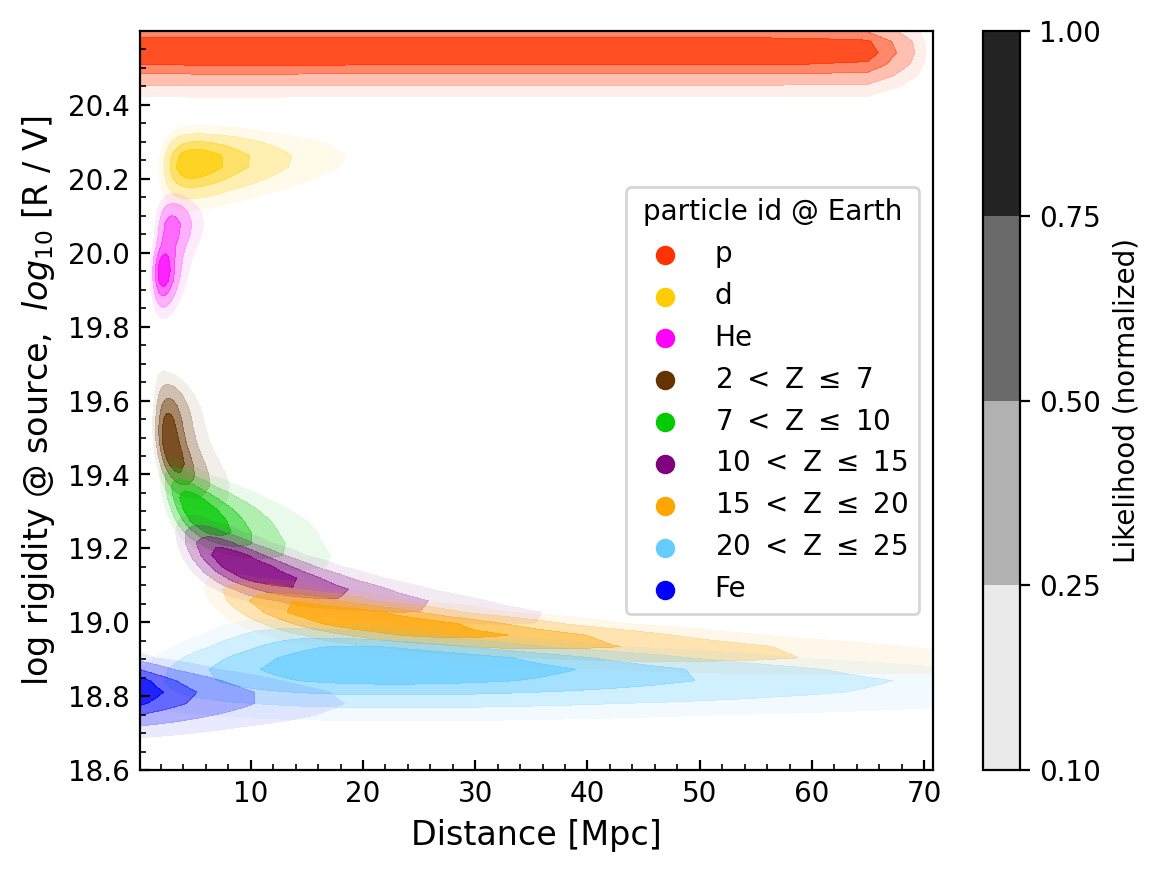

In [7]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
nlevels = [.1, .25, .5, .75, 1]

generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])

Zi, Ai = 26, 56
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
Zlims = [1, 2, 7, 10, 15, 20, 25]


plt.subplots(dpi=200)
for daughters, lab, col, contrib in zip([[(1, 1)], [(1, 2)]], ['p', 'd'], cols[:2], group_contributions[:2]):
    groupcmap = generate_cmap(col)
    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
    plt.scatter([], [], label=lab, c=col)


for zl, zh, contrib, col in zip(Zlims[:-1], Zlims[1:], group_contributions[2:], cols[2:]):
    clow = colorConverter.to_rgba(col, alpha=0)
    groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])

    Zvals = range(zl + 1, zh + 1)
    daughters = [spec for spec in ic1.species if spec[0] in Zvals]

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    lklhood[np.isnan(lklhood)] = 0
    
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

    if zl == 1:
        plt.scatter([], [], label=f'He', c=col)
    else:
        plt.scatter([], [], label=f'{zl} $<$ Z $\leq$ {zh}', c=col)
    

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(26, 56)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.scatter([], [], label='Fe', c=col)


sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.zeros_like(lklhood), levels=[np.round(lv, 2) for lv in nlevels], 
                  cmap=LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba('k', alpha=0), 'k']))
plt.colorbar(label='Likelihood (normalized)')
plt.ylim([18.6, 20.6])
plt.yticks(np.linspace(18.6, 20.4, 10));
plt.legend(loc='center right', title='particle id @ Earth')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()
# plt.semilogx() 


---

## Computing dist with injected Ca 40

In [8]:
br = np.logspace(9.2, 11.3, 17)
br = np.logspace(9.2, 11.3, 69)

L = np.logspace(-1, 1.85, 19)
L = np.logspace(-1, 1.85, 77)

group_contributions = [rig_dist_phasespace(Si=(20, 40), L=L, br=br, daughters=[(1, 1)]),
                       rig_dist_phasespace(Si=(20, 40), L=L, br=br, daughters=[(1, 2)], lyields_On=False)]

Zlims = [1, 2, 7, 10, 15, 19]

daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]

for zl, zh in zip(Zlims[:-1], Zlims[1:]):
    print(zl, zh)
    daughters = daughters_set(zl, zh)

    contributions = rig_dist_phasespace(Si=(20, 40), L=L, br=br, daughters=daughters, lyields_On=False)
    group_contributions.append(contributions)

group_contributions.append(rig_dist_phasespace(Si=(20, 40), L=L, br=br, daughters=[(20, 40)]))

1 2
2 7
7 10
10 15
15 19


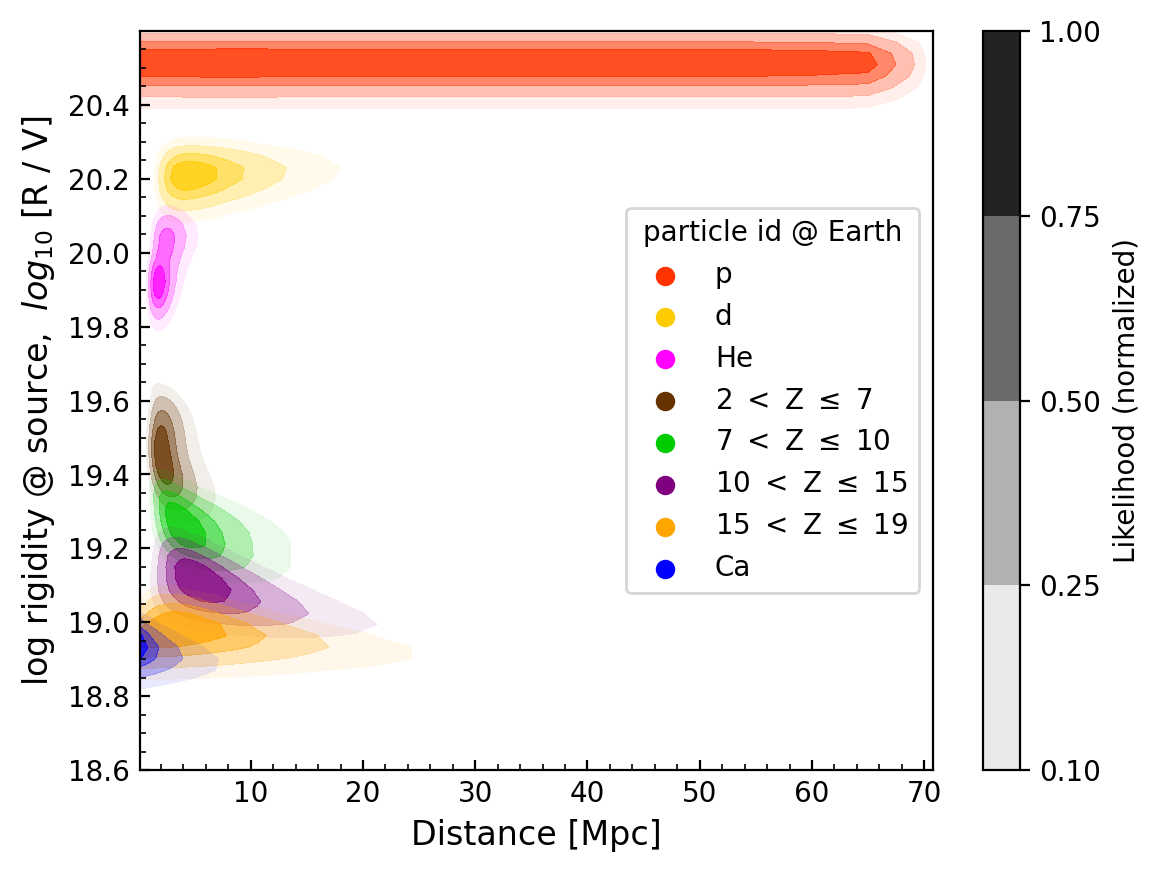

In [9]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
nlevels = [.1, .25, .5, .75, 1]

generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])

Zi, Ai = 20, 40
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
Zlims = [1, 2, 7, 10, 15, 19]


plt.subplots(dpi=200)
for daughters, lab, col, contrib in zip([[(1, 1)], [(1, 2)]], ['p', 'd'], cols[:2], group_contributions[:2]):
    groupcmap = generate_cmap(col)
    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
    plt.scatter([], [], label=lab, c=col)


for zl, zh, contrib, col in zip(Zlims[:-1], Zlims[1:], group_contributions[2:], cols[2:]):
    clow = colorConverter.to_rgba(col, alpha=0)
    groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])

    Zvals = range(zl + 1, zh + 1)
    daughters = [spec for spec in ic1.species if spec[0] in Zvals]

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    lklhood[np.isnan(lklhood)] = 0
    
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

    if zl == 1:
        plt.scatter([], [], label=f'He', c=col)
    else:
        plt.scatter([], [], label=f'{zl} $<$ Z $\leq$ {zh}', c=col)
    

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(20, 40)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.scatter([], [], label='Ca', c=col)


sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.zeros_like(lklhood), levels=[np.round(lv, 2) for lv in nlevels], 
                  cmap=LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba('k', alpha=0), 'k']))
plt.colorbar(label='Likelihood (normalized)')
plt.ylim([18.6, 20.6])
plt.yticks(np.linspace(18.6, 20.4, 10));
plt.legend(loc='center right', title='particle id @ Earth')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()
# plt.semilogx() 


---

## Computing dist with injected Si 28

In [12]:
br = np.logspace(9.2, 11.3, 17)
br = np.logspace(9.2, 11.3, 69)

L = np.logspace(-1, 1.85, 19)
L = np.logspace(-1, 1.85, 77)

group_contributions = [rig_dist_phasespace(Si=(14, 28), L=L, br=br, daughters=[(1, 1)]),
                       rig_dist_phasespace(Si=(14, 28), L=L, br=br, daughters=[(1, 2)], lyields_On=False)]

Zlims = [1, 2, 7, 10, 13]

daughters_set = lambda zl, zh: [spec for spec in ic1.species if spec[0] in range(zl + 1, zh + 1)]

for zl, zh in zip(Zlims[:-1], Zlims[1:]):
    print(zl, zh)
    daughters = daughters_set(zl, zh)

    contributions = rig_dist_phasespace(Si=(14, 28), L=L, br=br, daughters=daughters, lyields_On=False)
    group_contributions.append(contributions)

group_contributions.append(rig_dist_phasespace(Si=(14, 28), L=L, br=br, daughters=[(14, 28)]))

1 2
2 7
7 10
10 13


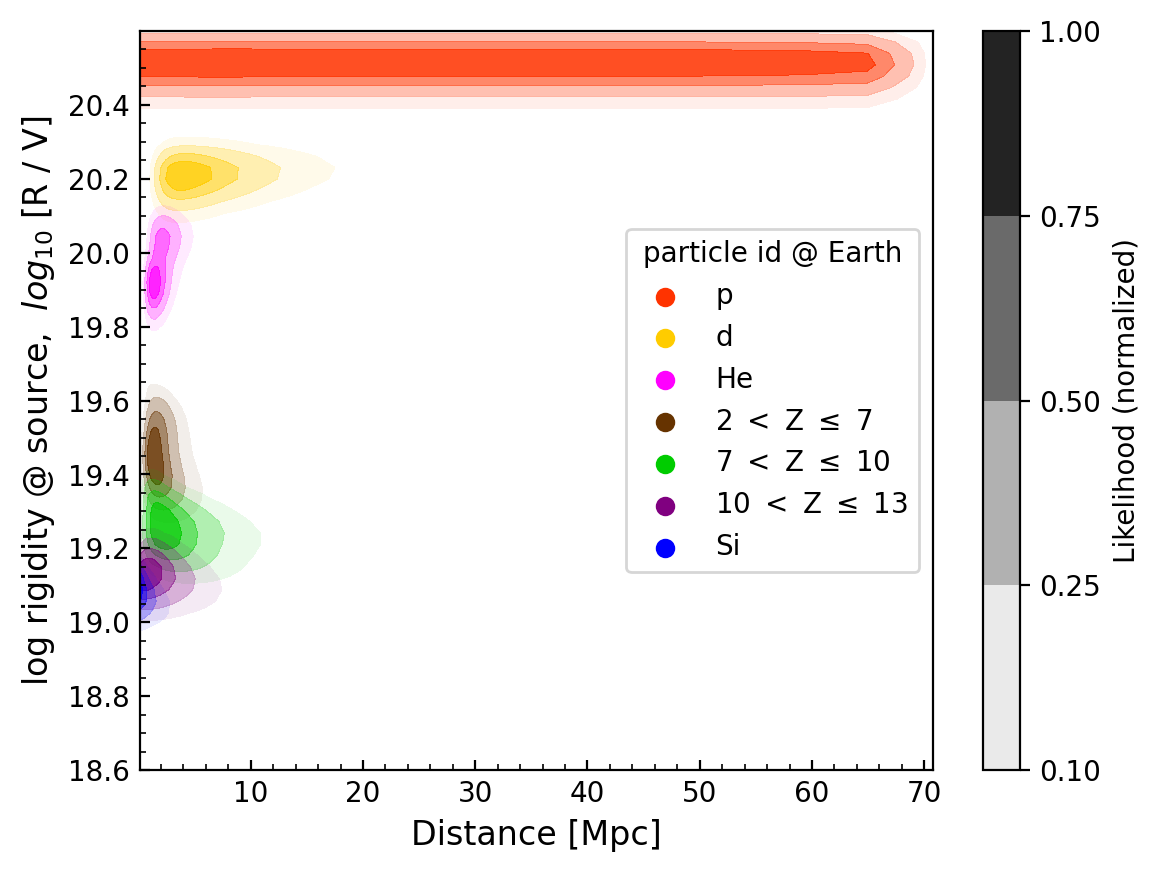

In [14]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter

cols = ['#ff3300', '#ffcc00', '#ff00ff', '#663300', '#00cc00', 'purple', 'orange', '#66ccff', '#0000cc']
nlevels = [.1, .25, .5, .75, 1]

generate_cmap = lambda col: LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba(col, alpha=0), col])

Zi, Ai = 14, 28
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
Zlims = [1, 2, 7, 10, 13]


plt.subplots(dpi=200)
for daughters, lab, col, contrib in zip([[(1, 1)], [(1, 2)]], ['p', 'd'], cols[:2], group_contributions[:2]):
    groupcmap = generate_cmap(col)
    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
    plt.scatter([], [], label=lab, c=col)


for zl, zh, contrib, col in zip(Zlims[:-1], Zlims[1:], group_contributions[2:], cols[2:]):
    clow = colorConverter.to_rgba(col, alpha=0)
    groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])

    Zvals = range(zl + 1, zh + 1)
    daughters = [spec for spec in ic1.species if spec[0] in Zvals]

    wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
    lklhood = sum([c * w for c, w in zip(contrib, wE)])
    lklhood[np.isnan(lklhood)] = 0
    
    plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

    if zl == 1:
        plt.scatter([], [], label=f'He', c=col)
    else:
        plt.scatter([], [], label=f'{zl} $<$ Z $\leq$ {zh}', c=col)
    

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(14, 28)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)
plt.scatter([], [], label='Si', c=col)


sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.zeros_like(lklhood), levels=[np.round(lv, 2) for lv in nlevels], 
                  cmap=LinearSegmentedColormap.from_list('somename', [colorConverter.to_rgba('k', alpha=0), 'k']))
plt.colorbar(label='Likelihood (normalized)')
plt.ylim([18.6, 20.6])
plt.yticks(np.linspace(18.6, 20.4, 10));
plt.legend(loc='center right', title='particle id @ Earth')
plt.xlabel('Distance [Mpc]', size=12)
plt.ylabel('log rigidity @ source,  $log_{10}$ [R / V]', size=12)
plt.tick_params(which='both', direction='in')
plt.minorticks_on()
# plt.semilogx() 


In [32]:
import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
   print(f.name)
for f in fm.fontManager.afmlist:
   print(f.name)

STIXGeneral
DejaVu Serif
DejaVu Serif
DejaVu Sans Display
DejaVu Sans Mono
cmss10
DejaVu Sans
STIXSizeOneSym
DejaVu Serif Display
STIXSizeThreeSym
STIXNonUnicode
STIXSizeOneSym
DejaVu Sans Mono
cmex10
cmb10
DejaVu Sans Mono
cmr10
STIXSizeFourSym
STIXSizeThreeSym
DejaVu Sans
cmmi10
DejaVu Sans
STIXGeneral
STIXSizeTwoSym
STIXNonUnicode
DejaVu Sans Mono
STIXNonUnicode
STIXSizeFourSym
STIXGeneral
cmtt10
STIXSizeTwoSym
DejaVu Serif
DejaVu Sans
DejaVu Serif
STIXNonUnicode
STIXGeneral
STIXSizeFiveSym
cmsy10
Ubuntu Mono
Lohit Tamil Classical
Verdana
Bitstream Vera Sans
Sarai
Noto Serif CJK JP
Source Code Pro
Tibetan Machine Uni
Verdana
Georgia
Courier New
Arial
Arial
Umpush
Padauk
Garuda
FreeSans
Umpush
Inconsolata
Nimbus Roman
Arial
DejaVu Math TeX Gyre
Kinnari
Ubuntu
Liberation Mono
Yrsa
Arial
Liberation Serif
Tlwg Typewriter
URW Gothic
Tlwg Mono
Arial
Andale Mono
Trebuchet MS
Ubuntu
Waree
Webdings
TenaliRamakrishna
Ubuntu
Arial
Source Code Pro
Noto Sans CJK JP
URW Gothic
Impact
cmr10
KacstP

In [12]:
len(group_contributions)
group_contributions[-2]

[array([[9.88629510e-03, 9.88100606e-03, 9.87524325e-03, ...,
         2.90133518e-04, 2.10942246e-04, 1.49020014e-04],
        [1.03874994e-02, 1.03817266e-02, 1.03754369e-02, ...,
         2.65835766e-04, 1.90900696e-04, 1.33055414e-04],
        [1.08043075e-02, 1.07981200e-02, 1.07913785e-02, ...,
         2.47254118e-04, 1.75772646e-04, 1.21169804e-04],
        ...,
        [1.34830835e+00, 1.23605514e+00, 1.12429913e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.39625624e+00, 1.27529417e+00, 1.15533102e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.43618472e+00, 1.30657936e+00, 1.17857439e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
 array([[3.03908608e-003, 3.04966607e-003, 3.06118576e-003, ...,
         2.31710077e-003, 1.83639156e-003, 1.41737558e-003],
        [3.44616401e-003, 3.45740656e-003, 3.46964683e-003, ...,
         2.15404073e-003, 1.68607587e-003, 1.28425701e-003],
        [3.86

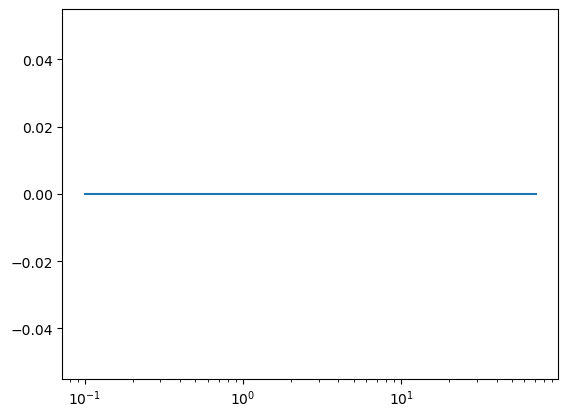

In [90]:
Zi, Ai = 26, 56
Zdet, Adet = 26, 56

alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(Ai, Adet-1), injection_type=('only species', (Zi, Ai)), absorption_type=('only species', [(Zdet, Adet)]))
_, total1 = ic1.pdf_boost_range(L, alpha, mr, boost_range=br, true_range=tr)

plt.semilogx(L, total1[40, :])


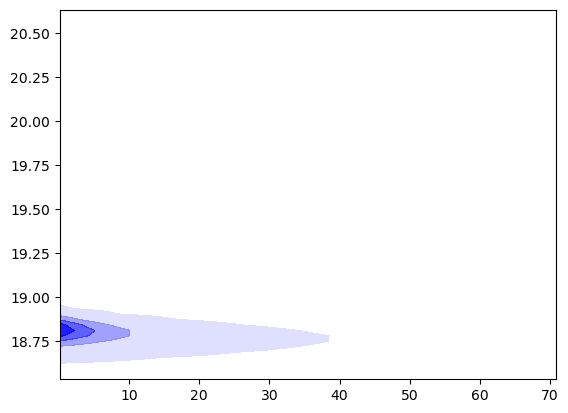

In [114]:
group_contributions[-1][0]

col = 'b'
clow = colorConverter.to_rgba(col, alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, col])
daughters = [(26, 56)]
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)
lklhood = sum([c * w for c, w in zip(group_contributions[-1], wE)])
sm = plt.contourf(L, np.log10(1e9 * br * Ai/Zi), lklhood / np.max(lklhood), levels=nlevels, cmap=groupcmap)

In [6]:
br = np.logspace(9.2, 11.3, 47)
L = np.logspace(-1, 1.6, 50)

Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty

Zi, Ai = 26, 56
Zvals = range(21, 26)
daughters = [spec for spec in ic1.species if spec[0] in Zvals]
print(daughters)

contributions = rig_dist_phasespace(daughters=daughters)
wE = apply_energy_weights(br, L, daughters, Ex=Ex, sgm=sgm)

[(25, 55), (25, 54), (24, 54), (25, 53), (24, 53), (23, 53), (25, 52), (24, 52), (23, 52), (22, 52), (25, 51), (24, 51), (23, 51), (22, 51), (21, 51), (24, 50), (23, 50), (22, 50), (21, 50), (24, 49), (23, 49), (22, 49), (21, 49), (24, 48), (23, 48), (22, 48), (21, 48), (23, 47), (22, 47), (21, 47), (22, 46), (21, 46), (22, 45), (21, 45), (22, 44), (21, 44), (21, 43)]


KeyboardInterrupt: 

In [23]:
for enu, mesch in enumerate(wE):
    contributions[enu] *= mesch

Text(0, 0.5, 'lg( rigidity @ source / V)')

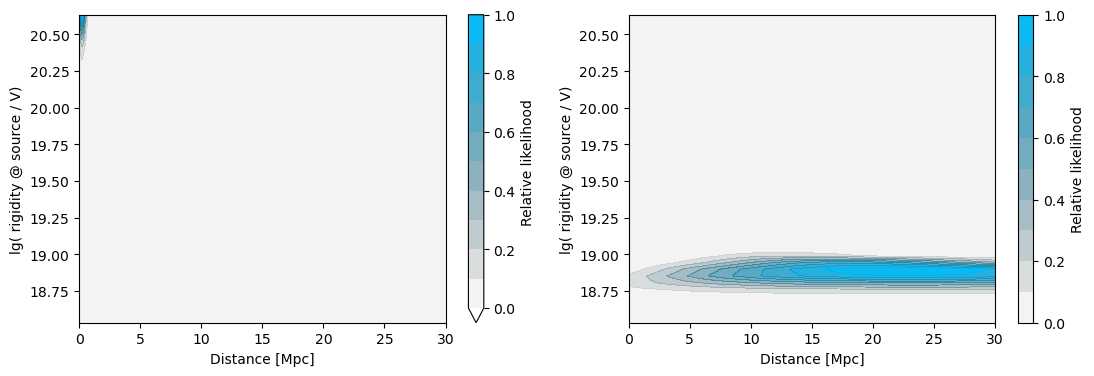

In [24]:
from matplotlib.colors import LinearSegmentedColormap
pbcmap = LinearSegmentedColormap.from_list('somename', ['#0b0ebd', '#F62459'])
groupcmap = LinearSegmentedColormap.from_list('somename', ['none', 'm'])
groupcmap = LinearSegmentedColormap.from_list('somename', ['none', 'brown'])
groupcmap = LinearSegmentedColormap.from_list('somename', ['none', 'g'])
groupcmap = LinearSegmentedColormap.from_list('somename', ['none', 'deepskyblue'])

f, axes = plt.subplots(1, 2, figsize=(13, 4))
plt.sca(axes[0])
# plt.contourf(L, np.log10(1e9 * br), np.log10(total1 / np.max(total1)), levels=np.linspace(-4, 0, 11)) # , cmap='bwr'
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), total1 / np.max(total1), levels=np.linspace(0, 1, 11), extend='min', cmap=groupcmap) # , cmap=pbcmap

plt.xlim(0, 30)
plt.colorbar(label='Relative likelihood')
plt.xlabel('Distance [Mpc]')
plt.ylabel('lg( rigidity @ source / V)')


plt.sca(axes[1])
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), sum(contributions) / np.max(sum(contributions)), levels=np.linspace(0, 1, 11), cmap=groupcmap)

plt.xlim(0, 30)
plt.colorbar(label='Relative likelihood')
plt.xlabel('Distance [Mpc]')
plt.ylabel('lg( rigidity @ source / V)')

In [26]:
br = np.logspace(9.2, 11.3, 47)
L = np.logspace(-1, 1.6, 50)

Zi, Ai = 26, 56
Zdet, Adet = 2, 4

# alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(Ai, Adet-1), injection_type=('only species', (Zi, Ai)), absorption_type=('only charge', [Zdet]))
alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(Ai, Adet-1), injection_type=('only species', (Zi, Ai)), absorption_type=('only species', [(Zdet, Adet)]))
_, total1 = ic1.pdf_boost_range(L, alpha, mr, boost_range=br, true_range=tr)

Text(0.5, 0, 'Rigidity @ source [V]')

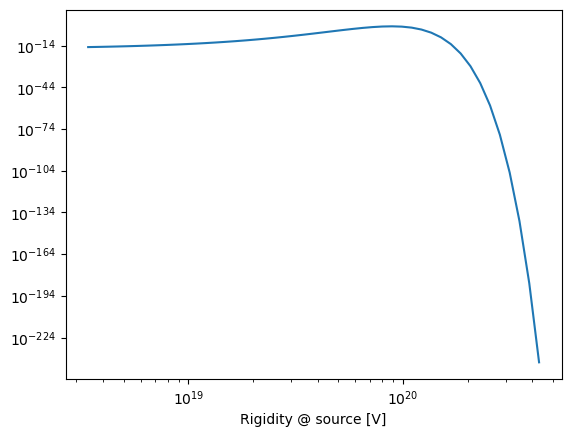

In [6]:
Ex = 1.64e11 # GeV, Elow
sgm = 0.19e11 # GeV, measurement uncertainty
wE = np.repeat(np.exp(-1/2*((Adet * br - Ex)/sgm)**2), len(L)).reshape(-1, len(L))
wR = 1

plt.plot(1e9 * br * Ai/Zi, np.exp(-1/2*((Adet * br - Ex)/sgm)**2))

plt.loglog()
plt.xlabel('Rigidity @ source [V]')

In [39]:
from matplotlib.colors import colorConverter
colorConverter.to_rgba('m', alpha=0)


(0.75, 0.0, 0.75, 0)

/tmp/ipykernel_491682/3669017343.py:16: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  plt.xlim(0, 30)
/tmp/ipykernel_491682/3669017343.py:29: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  plt.xlim(0, 30)


Text(0, 0.5, 'lg( rigidity @ source / V)')

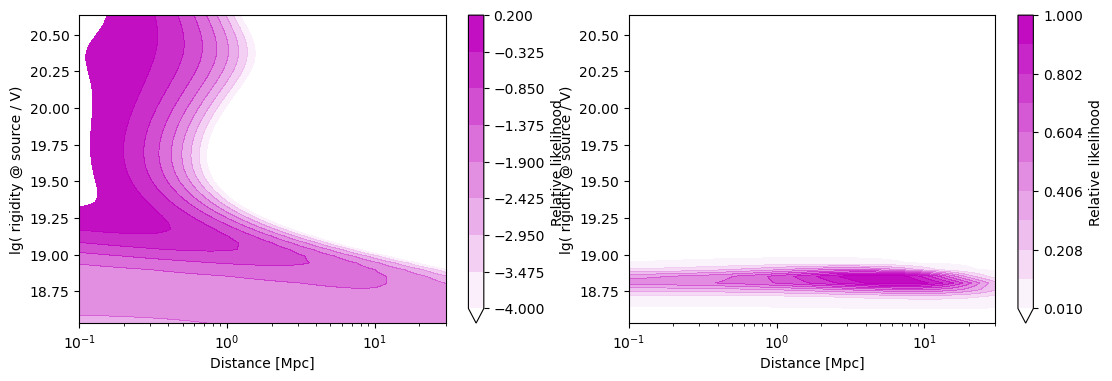

In [59]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import colorConverter
clow = colorConverter.to_rgba('m', alpha=0)
groupcmap = LinearSegmentedColormap.from_list('somename', [clow, 'm'])

k = 1
total1 = contributions[k]

f, axes = plt.subplots(1, 2, figsize=(13, 4))
plt.sca(axes[0])
# plt.contourf(L, np.log10(1e9 * br), np.log10(total1 / np.max(total1)), levels=np.linspace(-4, 0, 11)) # , cmap='bwr'
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), total1, levels=np.linspace(0, 1, 11), extend='min', cmap=groupcmap) # , cmap=pbcmap
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), np.log10(total1), levels=np.linspace(-4, 0.2, 9), extend='min', cmap=groupcmap) # , cmap=pbcmap

plt.semilogx()
plt.xlim(0, 30)
plt.colorbar(label='Relative likelihood')
plt.xlabel('Distance [Mpc]')
plt.ylabel('lg( rigidity @ source / V)')


plt.sca(axes[1])
# plt.contourf(L, np.log10(1e9 * br * Ai/Zi), wE * total1 / np.max(wE * total1), levels=np.linspace(0, 1, 11), extend='min', cmap=groupcmap)
plt.contourf(L, np.log10(1e9 * br * Ai/Zi), 
             (contributions[k] * wE[k]) / np.max(contributions[k] * wE[k]), levels=np.linspace(.01, 1, 11), extend='min', cmap=groupcmap)
            #  np.log10((contributions[k] * wE[k]) / np.max(contributions[k] * wE[k])), levels=np.linspace(-3, 0, 11), extend='min', cmap=groupcmap)

plt.semilogx()
plt.xlim(0, 30)
plt.colorbar(label='Relative likelihood')
plt.xlabel('Distance [Mpc]')
plt.ylabel('lg( rigidity @ source / V)')

In [ ]:
light_prods = ic1.light_secondaries_production(L, alpha, mr, boost_range=br, true_range=tr)

Text(0.5, 1.0, 'Cumulative yields w/o accounting for cascade')

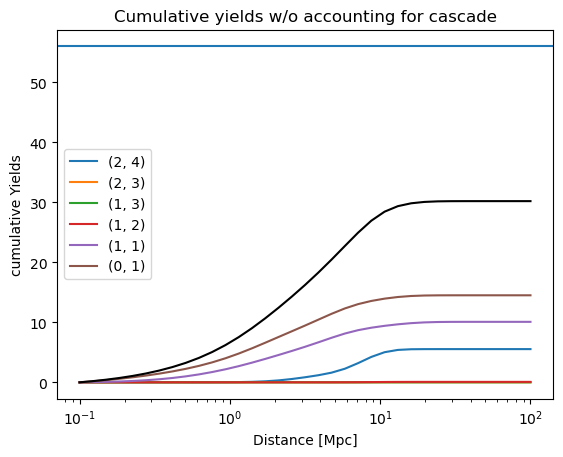

In [ ]:
daughters = [(2, 4), (2, 3), (1, 3), (1, 2), (1, 1), (0, 1)]
for nuc, row in zip(daughters, cumtrapz(light_prods, L, initial=0)):
    plt.semilogx(L, nuc[1] * row[7, :], label=nuc)

nucleons_light = np.einsum('i, ijk -> jk', np.array([A for _, A in daughters]), cumtrapz(light_prods, L, initial=0))
plt.semilogx(L, nucleons_light[7, :], c='k')
plt.axhline(56)
plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('cumulative Yields')
plt.title('Cumulative yields w/o accounting for cascade')

# Estimating extinsion distance

In [4]:
Zi, Ai = 2, 4
idx = ic1.species.index((Zi, Ai))

br = np.logspace(10.2, 11.2, 11)
L = -np.logspace(-.3, 1.1, 100)

alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only species', [(1, 1)]))
alpha[:] = 0
alpha[idx] = 1

spec_evol = ic1.species_evolution_boost_range(L, alpha, mr, br, tr)

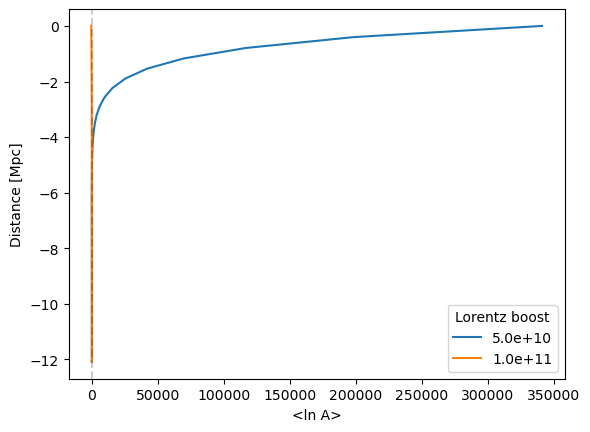

In [68]:
spec_evol

mass_vector = np.array([A for _, A in ic1.species])
mass_vector = np.array([np.log(A) for _, A in ic1.species])
mass_evol = np.einsum('ijk, k -> ij', spec_evol, mass_vector)

for k in [5, 8]:
    plt.plot(mass_evol[k, :], L[-1] - L, label=f'{br[k]:2.1e}')

plt.axvline(1.5, ls='--', c='k', alpha=.2)

plt.xlabel('<ln A>')
plt.ylabel('Distance [Mpc]')
plt.legend(title='Lorentz boost')

181

In [44]:
alpha

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

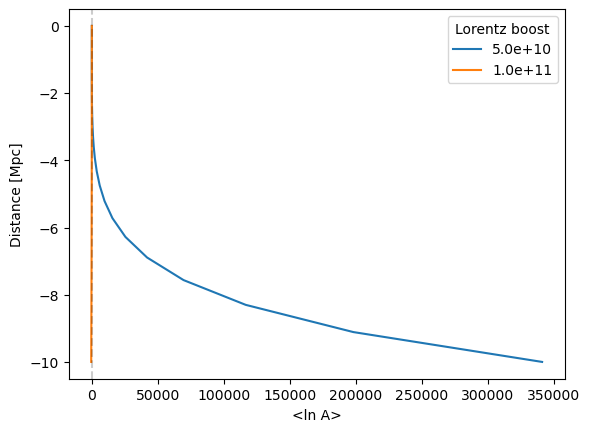

In [27]:
spec_evol

mass_vector = np.array([A for _, A in ic1.species])
mass_vector = np.array([np.log(A) for _, A in ic1.species])
mass_evol = np.einsum('ijk, k -> ij', spec_evol, mass_vector)

for k in [5, 8]:
    plt.plot(mass_evol[k, :], -L, label=f'{br[k]:2.1e}')

plt.axvline(1.5, ls='--', c='k', alpha=.2)

plt.xlabel('<ln A>')
plt.ylabel('Distance [Mpc]')
plt.legend(title='Lorentz boost')

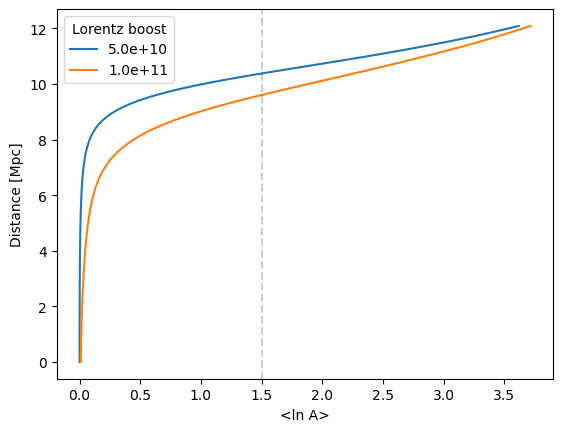

In [ ]:
spec_evol

mass_vector = np.array([A for _, A in ic1.species])
mass_vector = np.array([np.log(A) for _, A in ic1.species])
mass_evol = np.einsum('ijk, k -> ij', spec_evol, mass_vector)

for k in [5, 8]:
    plt.plot(mass_evol[k, :], L[-1] - L, label=f'{br[k]:2.1e}')

plt.axvline(1.5, ls='--', c='k', alpha=.2)

plt.xlabel('<ln A>')
plt.ylabel('Distance [Mpc]')
plt.legend(title='Lorentz boost')

In [39]:
def convert_to_intensity(mat):
    """Takes a matrix from the interactions tensor 
    and converts it into an intensity atrix by also
    making it irreducible 
    """
    disconnected = mat.dot(np.ones(len(mat))) == np.diag(A) # disconnected states
    disconnected[-1] = False # exception for absorbing states
    connected = np.logical_not(disconnected ) # states to be preserved

    irreducible = mat[connected][:, connected]

    intmat = np.block([[irreducible, -np.atleast_2d(irreducible.dot(np.ones(len(irreducible)))).T], [np.atleast_2d(np.zeros(len(irreducible) + 1))]])

    return intmat, connected 

In [73]:
from scipy.linalg import null_space, inv, expm

A = np.array([
    [-3, 2, 1],
    [0, -1, .1],
    [0, 0, 0]
])

maxid = 185
A = ic1.interpolator(3e10)[:maxid, :maxid]
A, connected = convert_to_intensity(A)

mass_vector = np.array([A for _, A in ic1.species[:maxid]])
# mass_vector = np.array([np.log(A) for _, A in ic1.species[:maxid]])
mass_vector = np.append(mass_vector[connected], mass_vector[connected][-1])

# mass_evol = np.einsum('ijk, k -> ij', spec_evol, mass_vector)

stdist = null_space(A).flatten()
stdist /= sum(stdist)
Abar = inv(np.diag(stdist)).dot(A.T).dot(np.diag(stdist))

In [44]:
Abar
A
len(stdist)

A.dot(np.ones_like(stdist)).dot(np.ones_like(stdist))

0.0

In [184]:
print(np.all(np.isclose(stdist, stdist[0])), stdist[0], sum(A.dot(stdist)))

True -0.5 -6.016723544026807e-15


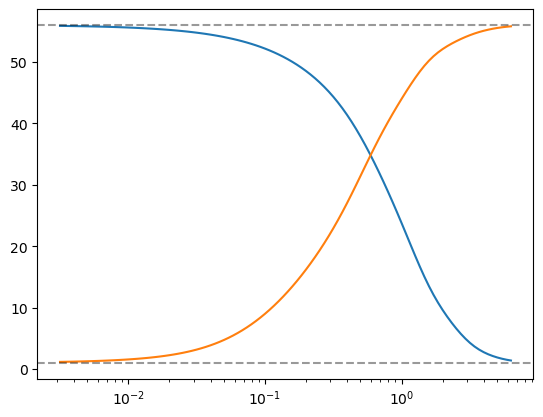

In [81]:
L = np.logspace(-2.5, .8, 100)

alpha = np.zeros(len(A))
alpha[0] = 1
# plt.semilogx(L, [alpha.dot(expm(A * Lval)).dot(np.ones_like(alpha)) for Lval in L])
plt.semilogx(L, [alpha.dot(expm(A * Lval)).dot(mass_vector) for Lval in L])


# Zi, Ai = 6, 12
# idx = ic1.species.index((Zi, Ai))

alpha = np.zeros(len(A))
alpha[0] = 1
# plt.plot(L, [expm(Abar * Lval).dot(alpha).dot(np.ones_like(alpha)) for Lval in L])
plt.plot(L, [mass_vector[::-1].dot(expm(Abar * Lval)).dot(alpha) for Lval in L])


plt.axhline(1, ls='--', c='k', alpha=.4)
plt.axhline(56, ls='--', c='k', alpha=.4)

In [127]:
expm(Abar * 100).dot(alpha) #.dot(np.ones_like(alpha))

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [214]:
from scipy.linalg import fractional_matrix_power
[fractional_matrix_power(expm(A), Lval) for Lval in L]


fractional_matrix_power(expm(Abar), 1e-3).dot([1, 0, 0, 0])

array([0.97230593, 0.01578372, 0.00400808, 0.00790227])

In [129]:
Abar[-5:, -5:]

array([[-0.24909241,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.24606179, -0.52684399,  0.        ,  0.        ,  0.        ],
       [ 0.00303062,  0.29424803, -0.59310863,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -1.65563795,  0.        ],
       [ 0.        ,  0.23259596,  0.59310863,  1.65563795,  0.        ]])

In [134]:
(np.ones(len(Abar))).dot(Abar)

array([-4.53565137e-15,  1.98838884e-14, -3.56152282e-14,  9.43564888e-15,
        2.21329031e-15,  1.23993968e-14,  1.06788493e-15, -1.20737296e-14,
        4.92607257e-15,  7.58827680e-15, -2.56966215e-14,  2.21457509e-14,
        2.71487477e-14,  1.51848477e-14, -4.51543100e-15, -5.86526270e-16,
       -4.30684134e-14,  6.44407216e-14,  3.64797439e-14,  1.71892665e-14,
        1.62417551e-14,  2.34295818e-14,  2.57191458e-14,  7.25762224e-14,
        3.68376662e-15,  3.05890296e-14,  1.31502882e-14, -1.49711515e-14,
        2.96054414e-14, -1.82829554e-14, -1.00825381e-15, -2.03968786e-14,
       -1.77288739e-15,  4.45843991e-14, -2.10149823e-14,  1.69181618e-14,
        1.29226057e-14, -3.37756353e-14, -3.00077888e-14,  7.68696630e-15,
        2.09119018e-14,  1.63888000e-14, -5.16427179e-15,  4.62385122e-15,
        1.66182172e-14,  2.76978418e-14,  1.56170649e-14, -7.12537668e-16,
       -1.64204587e-14,  9.14763057e-15, -1.13536567e-14, -7.71480319e-15,
        7.22946009e-15, -